# Understanding complexity measures

### How to tell a description length from a complexity measure

*(This notebook was previously called `understanding_d_wiring`. It has been
renamed and extended: the failure of `D_wiring` is now the setup, not the
conclusion, and §11 shows the measure that repairs it.)*

This notebook explains, slowly and from the beginning, one sentence that appears
in `method_comparison.ipynb`:

> *`D_wiring` separates 0% of same-degree graphs and produces a 0.000-correlated,
> manifestly wrong ordering on images. It is not a complexity measure and should
> stop being used as one.*

That sentence is doing a lot of work, and it deserves to be unpacked rather than
believed. By the end you will have:

* built `D_wiring` yourself, from nothing, in three lines;
* seen exactly which model it belongs to, what that model looks like, and how to
  *run* it;
* watched it fail on two real molecules a chemist can tell apart at a glance;
* watched it fail again on pictures, in a way that is not subtle;
* understood **why** it fails, from one plot.

**Nothing here requires you to trust me.** Every claim is followed by code you
can run and change.

**How to read it.** When you meet a **PREDICT** box, stop and commit to an answer
before running the next cell. That is not a ritual — a wrong guess is what makes
the explanation stick.

## §0. Setup

Select the `imp-pathinfo (.venv)` kernel and run this once.

In [1]:
import os, sys, math, itertools, warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))
sys.path.insert(0, os.path.join(os.path.dirname(ROOT), 'index-deconvolution', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import spearmanr

from imp_pathinfo import method_comparison as mc
from imp_pathinfo.bdm_complexity import bdm_engine
from imp_pathinfo.data import DATASET_ORDER, load_dataset
import causalbool as cb

engine = bdm_engine()
pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

def PREDICT(question, options):
    bar = '=' * 74
    print(bar); print('PREDICT  ->  ' + question)
    for i, o in enumerate(options, 1):
        print(f'            ({i}) {o}')
    print('            commit to an answer, then run the next cell'); print(bar)

print('ready')

ready


## §1. The everyday idea behind `D_wiring`

Imagine you must **write down a wiring diagram** and post it to someone. Not draw
it — *write* it, in words, so they can rebuild it exactly.

You would write something like:

```
There are 8 components.
Component 1 is fed by components 2 and 5.
Component 2 is fed by component 1.
Component 3 is fed by components 2, 4 and 7.
...
```

`D_wiring` is simply **the number of bits that letter takes**.

That is all it is. It is a *postage cost*. And here is the thing to hold on to
from the very start, because everything else follows from it:

> **The cost of writing an address does not tell you anything about who lives
> there.**

Writing "component 3 is fed by 2, 4 and 7" costs exactly as much as writing
"component 3 is fed by 1, 5 and 8". Same number of names, same postage. The two
wiring diagrams could behave completely differently, and the letter would be the
same length.

Hold that thought. It is the entire notebook.

## §2. Building the formula from nothing

### 2.1 How many bits to name a set?

Suppose there are **5** components, and I tell you component 3 is fed by
**exactly 2** of them. How many bits do you need from me to know *which* 2?

Well — how many possibilities are there? Choosing 2 things out of 5:

$$\binom{5}{2} = \frac{5 \times 4}{2 \times 1} = 10$$

Ten possibilities. To pick one out of ten you need $\log_2 10 \approx 3.32$ bits.
(If that is unfamiliar: 1 bit distinguishes 2 things, 2 bits distinguish 4,
3 bits distinguish 8, so ten things need a little over 3.)

So the rule is:

$$\text{bits to name the inputs of a node} \;=\; \log_2 \binom{n}{d}$$

where $n$ is how many components exist in total, and $d$ is how many feed this
particular node. In our language $d$ is the node's **degree**, and the set of
nodes that feed it is its **index set**.

Let us just count them out loud.

In [2]:
n = 5
rows = []
for d in range(n + 1):
    ways = math.comb(n, d)
    rows.append(dict(d_inputs=d, possible_index_sets=ways,
                     bits=round(math.log2(ways), 3)))
display(pd.DataFrame(rows).set_index('d_inputs'))

print('For n = 5, "which 2 of the 5 feed me?" has 10 answers, costing 3.32 bits.')
print('And here are those 10 answers, listed in full:')
print(' ', list(itertools.combinations(range(5), 2)))

,possible_index_sets,bits
d_inputs,,
0,1,0.000
1,5,2.322
2,10,3.322
3,10,3.322
4,5,2.322
5,1,0.000


For n = 5, "which 2 of the 5 feed me?" has 10 answers, costing 3.32 bits.
And here are those 10 answers, listed in full:
  [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


### 2.2 The whole formula

To describe the *entire* wiring you pay that cost once per node, plus a small
amount to say how many components there are in the first place:

$$D_{\text{wiring}} \;=\; \underbrace{\log_2 n}_{\text{how many components}} \;+\; \sum_{v} \underbrace{\log_2 \binom{n}{d_v}}_{\text{who feeds node } v}$$

That is the whole thing. Three lines of code.

In [3]:
def D_wiring(A):
    # A is an adjacency matrix: A[i][j] = 1 means j feeds i.
    A = np.asarray(A)
    n = A.shape[0]
    degrees = A.sum(axis=1)                       # how many inputs each node has
    return math.log2(n) + sum(math.log2(math.comb(n, int(d))) for d in degrees)

# sanity check against the project's own implementation
A_demo = np.array([[0,1,0,0,1],
                   [1,0,0,0,0],
                   [0,1,0,1,0],
                   [0,0,1,0,1],
                   [1,0,0,1,0]])
print('ours   :', round(D_wiring(A_demo), 4))
print('project:', round(mc.wiring_description_length(A_demo), 4))
print('degrees:', A_demo.sum(axis=1))

ours   : 17.9316
project: 17.9316
degrees: [2 1 2 2 2]


**Notice what that function touched.** It called `A.sum(axis=1)` — the number of
1s in each row — and then never looked at `A` again.

It never asked *which* entries were 1. Only *how many*.

That single line is the reason for everything that follows.

## §3. What model is this? What does it look like, and how do you run it?

`D_wiring` is not a free-floating formula. It prices one part of a specific kind
of model: a **Boolean network**. Let us build one, look at it, and run it, so
that "the model" is a concrete object rather than a word.

A Boolean network has exactly two parts:

1. **the wiring** — a matrix `C`, where `C[i][j] = 1` means *node j feeds node i*;
2. **the dynamics** — one logic gate per node, saying what it does with its inputs.

Each node is a switch that is either **0 (off)** or **1 (on)**. At every tick of
the clock, every node looks at the nodes that feed it and decides its next value.

In [4]:
C = [[0, 1, 0, 1],      # node 0 is fed by nodes 1 and 3
     [0, 0, 1, 0],      # node 1 is fed by node 2
     [1, 0, 0, 0],      # node 2 is fed by node 0
     [0, 1, 1, 0]]      # node 3 is fed by nodes 1 and 2
gates = ['AND', 'NOT', 'NOT', 'OR']

net = cb.Network(n=4, C=C, gates=gates)

print('THE MODEL, written out in full')
print()
print('wiring matrix C:')
print(np.array(C))
print()
for k in range(4):
    print(f'  node {k}: fed by {net.connected_inputs(k)},  gate = {gates[k]}')
print()
print('degrees (row sums):', np.array(C).sum(axis=1))
print()
print('D_wiring of this model: %.4f bits' % D_wiring(C))

THE MODEL, written out in full

wiring matrix C:
[[0 1 0 1]
 [0 0 1 0]
 [1 0 0 0]
 [0 1 1 0]]

  node 0: fed by [1, 3],  gate = AND
  node 1: fed by [2],  gate = NOT
  node 2: fed by [0],  gate = NOT
  node 3: fed by [1, 2],  gate = OR

degrees (row sums): [2 1 1 2]

D_wiring of this model: 11.1699 bits


### 3.1 Running the model, one tick at a time

Now let us actually *use* it. Give the network a starting state — a value for
each node — and ask what happens next.

In [5]:
state = [1, 0, 1, 0]        # node0=on, node1=off, node2=on, node3=off
print('current state :', state)
print()
for k in range(4):
    inputs = net.connected_inputs(k)
    values = [state[i] for i in inputs]
    result = cb.apply_gate(gates[k], values, {})
    print(f'  node {k}: gate {gates[k]:4s} applied to nodes {inputs} '
          f'which are {values}  ->  {result}')

print()
print('next state    :', cb.step(net, state))

current state : [1, 0, 1, 0]

  node 0: gate AND  applied to nodes [1, 3] which are [0, 0]  ->  0
  node 1: gate NOT  applied to nodes [2] which are [1]  ->  0
  node 2: gate NOT  applied to nodes [0] which are [1]  ->  0
  node 3: gate OR   applied to nodes [1, 2] which are [0, 1]  ->  1

next state    : [0, 0, 0, 1]


### 3.2 The full behaviour: every possible input

With 4 nodes there are $2^4 = 16$ possible states. Feed the network each one in
turn and record what comes out. That complete table is the **output repertoire** —
the model's entire behaviour, with nothing left out.

In [6]:
rep = cb.repertoire(net)
table = pd.DataFrame(rep, columns=[f'node{k} out' for k in range(4)])
table.insert(0, 'input state', [' '.join(str((x >> i) & 1) for i in range(4))
                                for x in range(16)])
display(table)
print('This 16 x 4 table is everything the model does. Nothing is hidden in it.')

,input state,node0 out,node1 out,node2 out,node3 out
0,0 0 0 0,0,1,1,0
1,1 0 0 0,0,1,0,0
2,0 1 0 0,0,1,1,1
3,1 1 0 0,0,1,0,1
4,0 0 1 0,0,0,1,1
5,1 0 1 0,0,0,0,1
6,0 1 1 0,0,0,1,1
7,1 1 1 0,0,0,0,1
8,0 0 0 1,0,1,1,0
9,1 0 0 1,0,1,0,0


This 16 x 4 table is everything the model does. Nothing is hidden in it.


### 3.3 The point of this section

Look back at what we have:

| the model has | `D_wiring` looks at |
| --- | --- |
| the wiring matrix `C` | **only its row sums** |
| which specific nodes feed which | **no** |
| the gates (`AND`, `NOT`, `OR`…) | **no** |
| the 16-row behaviour table | **no** |

`D_wiring` prices the *postage on the letter*. It never opens the envelope.

This is not a bug — it is honestly what the formula is for, and as a postage cost
it is exactly right. The mistake is asking it a question it was never built to
answer.

In [7]:
# Proof that D_wiring ignores the gates entirely: change every gate, keep the wiring.
for g in [['AND','NOT','NOT','OR'], ['OR','NOT','NOT','AND'], ['XOR','NOT','NOT','XOR']]:
    net_g = cb.Network(n=4, C=C, gates=g)
    rep_g = cb.repertoire(net_g)
    n_on = sum(sum(row) for row in rep_g)
    print(f'gates {str(g):34s}  D_wiring = {D_wiring(C):.4f}   '
          f'total "on" outputs in the behaviour table = {n_on}')
print()
print('Same number every time, while the behaviour changes underneath it.')

gates ['AND', 'NOT', 'NOT', 'OR']         D_wiring = 11.1699   total "on" outputs in the behaviour table = 32
gates ['OR', 'NOT', 'NOT', 'AND']         D_wiring = 11.1699   total "on" outputs in the behaviour table = 32
gates ['XOR', 'NOT', 'NOT', 'XOR']        D_wiring = 11.1699   total "on" outputs in the behaviour table = 32

Same number every time, while the behaviour changes underneath it.


## §4. First failure: two molecules a chemist can tell apart

Enough toys. Here are two **real molecules** from the datasets used in the paper.

* `C[C@@H]1CCCC[C@@H]1C` — a six-carbon ring with two methyl groups on
  **neighbouring** carbons.
* `Cc1cccc(c1)C` — a six-carbon ring with two methyl groups **separated by one
  carbon**.

Both have 8 heavy atoms. Both have exactly the same *degree sequence*: two atoms
with 1 bond, four with 2 bonds, two with 3 bonds. But they are different
molecules — different compounds, different boiling points, different smell.

Let us look at them.

In [8]:
smi_a, smi_b = 'C[C@@H]1CCCC[C@@H]1C', 'Cc1cccc(c1)C'

def graph_of(smiles):
    for name in DATASET_ORDER:
        for g in load_dataset(name).graphs:
            if g.smiles == smiles:
                return g
    raise KeyError(smiles)

ga, gb = graph_of(smi_a), graph_of(smi_b)
Aa, Ab = ga.adjacency().astype(int), gb.adjacency().astype(int)

deg_a, deg_b = sorted(Aa.sum(1).tolist()), sorted(Ab.sum(1).tolist())
print('molecule A:', smi_a, ' atoms:', ga.n_nodes, ' degrees:', deg_a)
print('molecule B:', smi_b, ' atoms:', gb.n_nodes, ' degrees:', deg_b)
print()
print('identical degree sequence:', deg_a == deg_b)
print('the same graph (isomorphic)?',
      nx.is_isomorphic(nx.from_numpy_array(Aa), nx.from_numpy_array(Ab)))

molecule A:

 C[C@@H]1CCCC[C@@H]1C  atoms: 8  degrees: [1, 1, 2, 2, 2, 2, 3, 3]
molecule B: Cc1cccc(c1)C  atoms: 8  degrees: [1, 1, 2, 2, 2, 2, 3, 3]

identical degree sequence: True
the same graph (isomorphic)? False


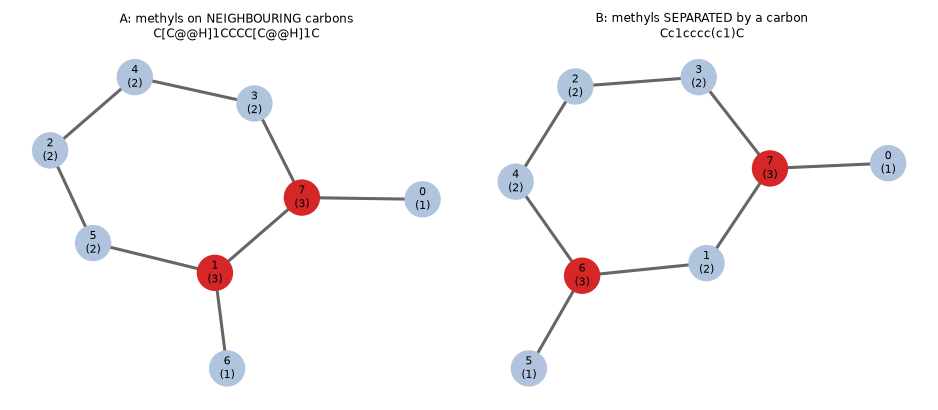

Red = the two atoms with 3 bonds. In A they touch. In B they do not.
That is a real, visible, chemical difference.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8))
for ax, A, smi, title in [(axes[0], Aa, smi_a, 'A: methyls on NEIGHBOURING carbons'),
                          (axes[1], Ab, smi_b, 'B: methyls SEPARATED by a carbon')]:
    G = nx.from_numpy_array(A)
    pos = nx.kamada_kawai_layout(G)
    deg = dict(G.degree())
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=520,
                           node_color=['tab:red' if deg[i] == 3 else 'lightsteelblue'
                                       for i in G.nodes()])
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={i: f'{i}\n({deg[i]})' for i in G.nodes()}, font_size=7)
    ax.set_title(f'{title}\n{smi}', fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()
print('Red = the two atoms with 3 bonds. In A they touch. In B they do not.')
print('That is a real, visible, chemical difference.')

### PREDICT

In [10]:
PREDICT('These two molecules are genuinely different. What will D_wiring say?',
        ['different values, since the molecules are different',
         'the same value, because the degree sequences match',
         'similar but not equal values'])

PREDICT  ->  These two molecules are genuinely different. What will D_wiring say?
            (1) different values, since the molecules are different
            (2) the same value, because the degree sequences match
            (3) similar but not equal values
            commit to an answer, then run the next cell


In [11]:
print('molecule A: D_wiring = %.6f' % D_wiring(Aa))
print('molecule B: D_wiring = %.6f' % D_wiring(Ab))
print()
print('difference: %.10f' % abs(D_wiring(Aa) - D_wiring(Ab)))
print()
print('For contrast, BDM sees the two adjacency matrices as different:')
print('  BDM(A) = %.3f    BDM(B) = %.3f' % (engine.bdm(Aa), engine.bdm(Ab)))

molecule A: D_wiring = 39.844130
molecule B: D_wiring = 39.844130

difference: 0.0000000000

For contrast, BDM sees the two adjacency matrices as different:
  BDM(A) = 80.746    BDM(B) = 113.160


### What just happened

`D_wiring` gave **exactly the same number** — not close, identical to ten decimal
places. And it had to, because the only thing it looked at was `A.sum(axis=1)`,
and those row sums are the same by construction.

Read the letter it would write for each molecule:

* A: *"8 atoms. One atom has 1 bond. One atom has 1 bond. One has 2. …"*
* B: *"8 atoms. One atom has 1 bond. One atom has 1 bond. One has 2. …"*

Identical letters. The information that distinguishes the molecules — **which**
atoms are bonded to **which** — was never written down.

## §5. Is that just one unlucky pair? No — it is 0 out of 250

One example proves nothing. So the same test was run at scale: **250 pairs of
real molecules**, each pair sharing a degree sequence, each pair verified to be
genuinely different graphs by a full isomorphism test.

In [12]:
ds = [load_dataset(n) for n in DATASET_ORDER]
pairs = mc.same_degree_pairs(ds, min_atoms=6, max_atoms=13, max_pairs=250, seed=0)
print(f'{len(pairs)} pairs of real, non-isomorphic molecules with matching degrees')

separated = sum(1 for (_, A1, _), (_, A2, _) in pairs
                if abs(mc.wiring_description_length(A1) - mc.wiring_description_length(A2)) > 1e-9)
print()
print(f'pairs D_wiring can tell apart: {separated} out of {len(pairs)}  '
      f'= {100 * separated / len(pairs):.1f}%')

250 pairs of real, non-isomorphic molecules with matching degrees

pairs D_wiring can tell apart: 0 out of 250  = 0.0%


**Zero.** Not "a few", not "a low percentage" — none of them, and none of them
*could* have been. This is not a measurement of how well `D_wiring` performs; it
is a demonstration of what it is mathematically incapable of seeing.

A measure that assigns the same number to every graph with the same degree
sequence cannot be measuring structure, because structure is exactly the thing
that varies while the degree sequence is held fixed.

## §6. Second failure: pictures

Molecular graphs are a special world. Let us try something completely different —
**pictures** — where we can *see* with our own eyes which one is simple and which
is complicated, and check whether the numbers agree.

Five black-and-white images, each 16 × 16:

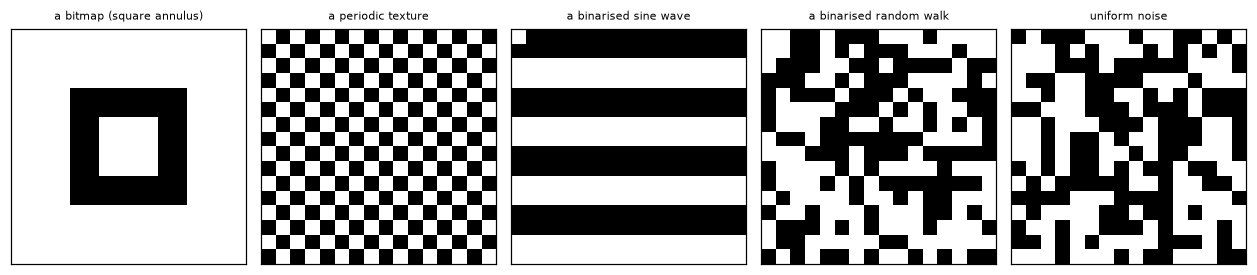

Your own eyes rank these easily: the checkerboard is the simplest thing
here -- you could describe it in one sentence. The noise is the hardest.


In [13]:
objs = mc.non_graph_objects()
fig, axes = plt.subplots(1, 5, figsize=(11.5, 2.7))
for ax, (label, obj) in zip(axes, objs.items()):
    ax.imshow(obj, cmap='Greys', interpolation='nearest')
    ax.set_title(label, fontsize=7.5); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print('Your own eyes rank these easily: the checkerboard is the simplest thing')
print('here -- you could describe it in one sentence. The noise is the hardest.')

### PREDICT

In [14]:
PREDICT('If we score these with BDM and with D_wiring, what do you expect?',
        ['both will rank the checkerboard simplest and the noise most complex',
         'BDM will get it right; D_wiring will get it roughly right',
         'BDM will get it right; D_wiring will get it badly wrong'])

PREDICT  ->  If we score these with BDM and with D_wiring, what do you expect?
            (1) both will rank the checkerboard simplest and the noise most complex
            (2) BDM will get it right; D_wiring will get it roughly right
            (3) BDM will get it right; D_wiring will get it badly wrong
            commit to an answer, then run the next cell


In [15]:
rows = []
for label, obj in objs.items():
    A = np.asarray(obj, dtype=int)
    rows.append(dict(image=label, BDM=round(engine.bdm(A), 1),
                     D_wiring=round(D_wiring(A), 1),
                     mean_degree=round(A.sum(1).mean(), 2)))
scores = pd.DataFrame(rows).set_index('image')
display(scores)

print('ranked by BDM      (simplest first):')
for i, name in enumerate(scores.sort_values('BDM').index, 1):
    print(f'   {i}. {name}')
print('ranked by D_wiring (simplest first):')
for i, name in enumerate(scores.sort_values('D_wiring').index, 1):
    print(f'   {i}. {name}')
print()
print('Spearman rank correlation between the two: %+.3f'
      % spearmanr(scores.BDM, scores.D_wiring).statistic)

,BDM,D_wiring,mean_degree
image,,,
a bitmap (square annulus),132.8,101.9,3.00
a periodic texture,34.3,222.4,8.00
a binarised sine wave,62.5,8.0,7.94
a binarised random walk,495.4,207.1,7.75
uniform noise,498.9,217.6,7.88


ranked by BDM      (simplest first):
   1. a periodic texture
   2. a binarised sine wave
   3. a bitmap (square annulus)
   4. a binarised random walk
   5. uniform noise
ranked by D_wiring (simplest first):
   1. a binarised sine wave
   2. a bitmap (square annulus)
   3. a binarised random walk
   4. uniform noise
   5. a periodic texture

Spearman rank correlation between the two: +0.000


### Read that carefully

Two things happened, and the second is worse than the first.

**First**, the rank correlation is **0.000**. Not weak — *nothing*. The two
orderings are unrelated.

**Second, and this is the damning part**: `D_wiring` ranks the **checkerboard as
the most complex image of the five** — more complex than uniform random noise.

You can see the checkerboard is the simplest object on the page. You could
describe it to someone over the telephone in five seconds. `D_wiring` says it is
the hardest to describe of all five.

Let us plot it so there is no ambiguity.

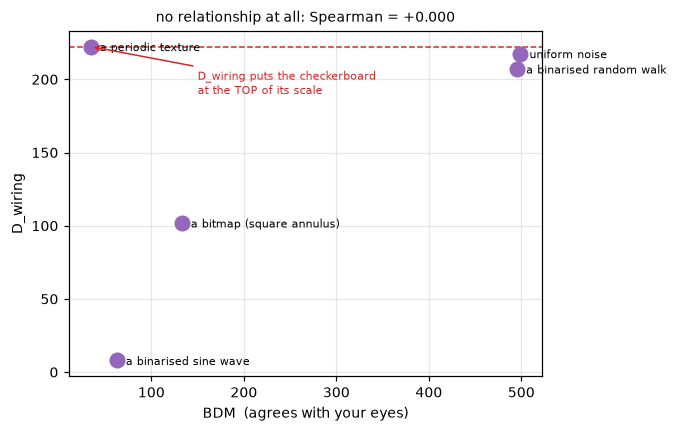

In [16]:
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.scatter(scores.BDM, scores.D_wiring, s=90, color='tab:purple', zorder=3)
for name, r in scores.iterrows():
    ax.annotate(name, (r.BDM, r.D_wiring), fontsize=7.5,
                xytext=(6, -3), textcoords='offset points')
ax.set_xlabel('BDM  (agrees with your eyes)')
ax.set_ylabel('D_wiring')
ax.set_title('no relationship at all: Spearman = %+.3f'
             % spearmanr(scores.BDM, scores.D_wiring).statistic, fontsize=9)
ax.grid(alpha=0.3)
ax.axhline(scores.loc['a periodic texture', 'D_wiring'], ls='--', c='tab:red', lw=1)
ax.annotate('D_wiring puts the checkerboard\nat the TOP of its scale',
            xy=(scores.loc['a periodic texture', 'BDM'],
                scores.loc['a periodic texture', 'D_wiring']),
            xytext=(150, 190), fontsize=7.5, color='tab:red',
            arrowprops=dict(arrowstyle='->', color='tab:red'))
plt.tight_layout(); plt.show()

## §7. Why? One plot explains everything

Why on earth would a checkerboard score as maximally complex?

Read the image as a wiring matrix, as `D_wiring` does. Row $i$ of a checkerboard
is `1 0 1 0 1 0 …` — **exactly 8 ones out of 16**. Every single row. So every
"node" has degree 8.

Now recall the formula: the cost per node is $\log_2\binom{n}{d}$. Let us plot
that quantity against $d$ and see where it is largest.

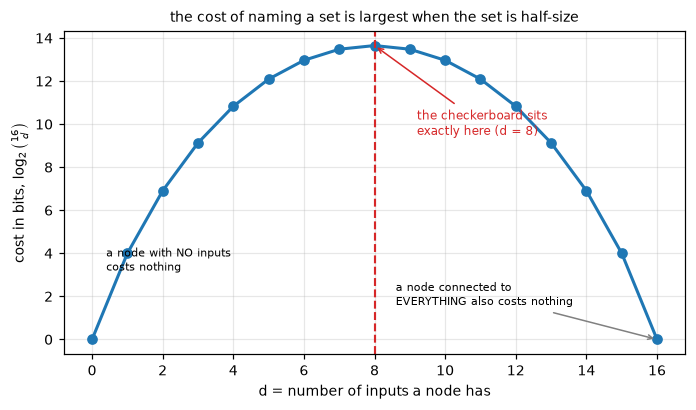

cost at d=0  : 0.00 bits   (only one possible answer: "nobody")
cost at d=8  : 13.65 bits   (12,870 possible answers -- the maximum)
cost at d=16 : 0.00 bits   (only one possible answer: "everybody")


In [17]:
n = 16
d_vals = np.arange(n + 1)
bits = np.array([math.log2(math.comb(n, int(d))) for d in d_vals])

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(d_vals, bits, 'o-', color='tab:blue', lw=2)
ax.axvline(8, color='tab:red', ls='--', lw=1.4)
ax.annotate('the checkerboard sits\nexactly here (d = 8)', xy=(8, bits[8]),
            xytext=(9.2, 9.5), fontsize=8, color='tab:red',
            arrowprops=dict(arrowstyle='->', color='tab:red'))
ax.annotate('a node with NO inputs\ncosts nothing', xy=(0, 0), xytext=(0.4, 3.2), fontsize=7.5)
ax.annotate('a node connected to\nEVERYTHING also costs nothing',
            xy=(16, 0), xytext=(8.6, 1.6), fontsize=7.5,
            arrowprops=dict(arrowstyle='->', color='grey'))
ax.set_xlabel('d = number of inputs a node has')
ax.set_ylabel(r'cost in bits, $\log_2\binom{16}{d}$')
ax.set_title('the cost of naming a set is largest when the set is half-size', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('cost at d=0  : %.2f bits   (only one possible answer: "nobody")' % bits[0])
print('cost at d=8  : %.2f bits   (12,870 possible answers -- the maximum)' % bits[8])
print('cost at d=16 : %.2f bits   (only one possible answer: "everybody")' % bits[16])

### There it is

The curve is a hill with its peak in the middle. And the reason is pure counting:

* if a node has **0** inputs, there is only **one** possible answer to "which
  ones?" — nobody. Nothing to say, zero bits.
* if a node has **all 16** inputs, again only **one** possible answer —
  everybody. Zero bits.
* if a node has **8** inputs, there are $\binom{16}{8} = 12{,}870$ possible
  answers. Maximum uncertainty, maximum bits.

The checkerboard has every node at exactly $d = 8$: **the worst possible place on
this curve**. So it scores the maximum. Not because it is complicated — because
"half of them" is the most expensive quantity of things to *name*.

This is `D_wiring` behaving perfectly correctly and answering a completely
different question from the one we asked. It answers *"how expensive is this
address to write down?"* We wanted to know *"is this picture complicated?"*

For a checkerboard the honest answers are: **expensive to address, trivial to
describe.**

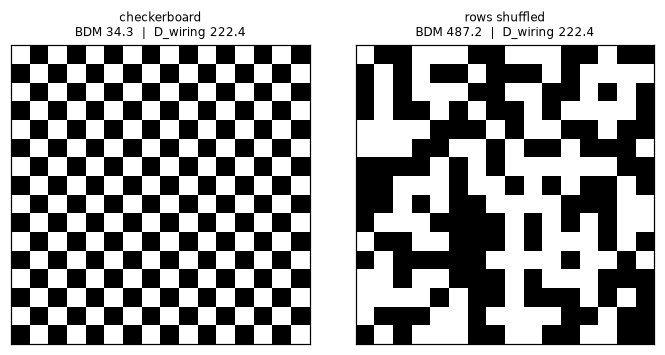

Every row still has 8 ones, so D_wiring is unchanged to the last decimal.
BDM notices immediately that the pattern is gone.

D_wiring  before 222.4276 -> after 222.4276   (identical)
BDM       before 34.27 -> after 487.22


In [18]:
# The same point, made without any theory: shuffle a checkerboard's pixels.
rng = np.random.default_rng(0)
tex = np.indices((16, 16)).sum(axis=0) % 2
shuffled = tex.copy()
for i in range(16):
    rng.shuffle(shuffled[i])            # destroy the pattern, keep each row's count

fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.2))
for ax, img, t in [(axes[0], tex, 'checkerboard'), (axes[1], shuffled, 'rows shuffled')]:
    ax.imshow(img, cmap='Greys', interpolation='nearest')
    ax.set_title(f'{t}\nBDM {engine.bdm(img):.1f}  |  D_wiring {D_wiring(img):.1f}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print('Every row still has 8 ones, so D_wiring is unchanged to the last decimal.')
print('BDM notices immediately that the pattern is gone.')
print()
print('D_wiring  before %.4f -> after %.4f   (identical)' % (D_wiring(tex), D_wiring(shuffled)))
print('BDM       before %.2f -> after %.2f' % (engine.bdm(tex), engine.bdm(shuffled)))

## §8. So is `D_wiring` wrong?

No — and this distinction matters.

**`D_wiring` is correct at its job.** If you genuinely need to post a wiring
diagram, $\log_2\binom{n}{d}$ really is what it costs, and the formula is exact,
needs no lookup table, and does not change if you renumber the nodes. As a
*description length for wiring*, it is right.

**It is wrong as a complexity measure**, because complexity is about the thing
described, and `D_wiring` never looks at the thing described. It is the length of
the address, not a description of the house.

| question | is `D_wiring` the right tool? |
| --- | --- |
| How many bits to transmit this wiring diagram? | **yes**, exactly right |
| How many inputs does this network have in total? | **yes** |
| Are these two networks structurally different? | **no** — 0% of 250 pairs |
| Is this picture simple or complicated? | **no** — ranks a checkerboard hardest |
| How much algorithmic structure is here? | **no**, and it cannot be |

### The two-sentence version

> `D_wiring` counts how expensive the *names* are.
> Complexity is about the *pattern*, and the names were never the pattern.

## §9. What to use instead

The wiring term is the cheapest and shallowest layer of the index-set calculus.
Three better things sit above it, all measured in `method_comparison.ipynb`:

| instead of `D_wiring` | what it looks at | separates the 250 pairs |
| --- | --- | --- |
| **query overlap** (order 2 or 3) | how much the inputs of several nodes *share* | 97.6% / **100%** |
| **repertoire landscape** | what the network actually *does* over all states | 93–96% |
| **program length** | the bits of a *recovered mechanism* that replays the object | — (it is a bound on $K$) |

The common thread: each of these opens the envelope. They look at which nodes are
connected to which, or at what the system does, rather than at how many names
must be written.

Here is the cheapest of them on our two molecules from §4 — the ones `D_wiring`
could not tell apart.

In [19]:
print('the pair D_wiring could not distinguish:')
print('  A =', smi_a)
print('  B =', smi_b)
print()
print('%-34s %14s %14s %10s' % ('measure', 'molecule A', 'molecule B', 'different?'))

def show(label, fa, fb, fmt='{:.4f}'):
    va, vb = fa, fb
    same = (va == vb)
    print('%-34s %14s %14s %10s'
          % (label, fmt.format(va) if not isinstance(va, str) else va,
             fmt.format(vb) if not isinstance(vb, str) else vb,
             'no' if same else 'YES'))

show('D_wiring', D_wiring(Aa), D_wiring(Ab))
show('query overlap, order 2', hash(mc.query_overlap_profile(Aa, 2)) % 10**6,
     hash(mc.query_overlap_profile(Ab, 2)) % 10**6, '{:d}')
show('query overlap, order 3', hash(mc.query_overlap_profile(Aa, 3)) % 10**6,
     hash(mc.query_overlap_profile(Ab, 3)) % 10**6, '{:d}')
show('BDM', engine.bdm(Aa), engine.bdm(Ab), '{:.2f}')

print()
print('(the query-overlap rows show a short fingerprint of the full profile,')
print(' just so the two can be compared at a glance)')
print()
print('order-2 profile A:', mc.query_overlap_profile(Aa, 2))
print('order-2 profile B:', mc.query_overlap_profile(Ab, 2))

the pair D_wiring could not distinguish:
  A = C[C@@H]1CCCC[C@@H]1C
  B = Cc1cccc(c1)C

measure                                molecule A     molecule B different?
D_wiring                                  39.8441        39.8441         no
query overlap, order 2                     902002         164291        YES
query overlap, order 3                     625086         631810        YES
BDM                                         80.75         113.16        YES

(the query-overlap rows show a short fingerprint of the full profile,
 just so the two can be compared at a glance)

order-2 profile A: (2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6)
order-2 profile B: (2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5)


---

## §11. The repair: a measure that *does* look inside

Everything so far has been a diagnosis. Here is the cure, and it is not
complicated.

### 11.1 The idea

`D_wiring` asked each node one question: **"how many inputs do you have?"** — and
threw away the answer to "*which* ones?".

The repair asks a question about **pairs** of nodes instead:

> *If I want to know what nodes $i$ and $j$ are doing, how many other nodes do I
> have to look at?*

The answer is the size of $N(i) \cup N(j)$ — the inputs of $i$ together with the
inputs of $j$. And that number is **not** determined by the degrees, because it
depends on whether their inputs **overlap**.

* If $i$ and $j$ share neighbours, the union is small — you look at few nodes.
* If they share none, the union is large.

Two nodes of degree 3 each might need 6 nodes examined, or as few as 3. The degree
sequence cannot tell you which. **That gap is exactly the structure `D_wiring`
lost.**

This is not something invented for this notebook. It is what the method already
does: `onPossibleBehaviour` answers any query by enumerating `joinedNames`, the
union of the index sets involved, and folding everything else into the
**sumandos**. The offset family has $2^{\,n - |joinedNames|}$ members, so

$$\log_2|\Omega| \;=\; n - |joinedNames|$$

is the number of bits the compressed answer spends on the free part. Averaging
that over all pairs gives one number per graph.

In [20]:
def profile(A, order=2):
    # the FULL multiset of "how many nodes are not needed", one entry per group
    A = np.asarray(A); n = A.shape[0]
    nb = [set(np.nonzero(A[i])[0].tolist()) for i in range(n)]
    return tuple(sorted(n - len(set().union(*[nb[i] for i in c]))
                        for c in itertools.combinations(range(n), order)))

def spread(A, order=2):
    # the SHAPE of that multiset, not its average
    return float(np.std(profile(A, order)))

def sumando_bits(A, order=2):
    # For every group of `order` nodes: how many nodes are NOT in the union of
    # their input sets?  That count is log2 of the number of sumandos.
    A = np.asarray(A); n = A.shape[0]
    nb = [set(np.nonzero(A[i])[0].tolist()) for i in range(n)]
    return float(np.mean([n - len(set().union(*[nb[i] for i in combo]))
                          for combo in itertools.combinations(range(n), order)]))

print('the two molecules D_wiring could not tell apart:')
print('  A =', smi_a, ' (methyls on neighbouring carbons)')
print('  B =', smi_b, ' (methyls separated)')
print()
print('%-22s %12s %12s %s' % ('measure', 'molecule A', 'molecule B', 'different?'))
for label, va, vb in [('D_wiring', D_wiring(Aa), D_wiring(Ab)),
                      ('sumando bits (k=2)', sumando_bits(Aa, 2), sumando_bits(Ab, 2)),
                      ('sumando bits (k=3)', sumando_bits(Aa, 3), sumando_bits(Ab, 3))]:
    print('%-22s %12.5f %12.5f %s'
          % (label, va, vb, 'no' if abs(va - vb) < 1e-9 else 'YES'))

the two molecules D_wiring could not tell apart:
  A = C[C@@H]1CCCC[C@@H]1C  (methyls on neighbouring carbons)
  B = Cc1cccc(c1)C  (methyls separated)

measure                  molecule A   molecule B different?
D_wiring                   39.84413     39.84413 no
sumando bits (k=2)          4.35714      4.35714 no
sumando bits (k=3)          3.03571      3.03571 no


There it is. The same two molecules, the same adjacency matrices — and a measure
that reads *overlap* rather than *counts* separates them immediately.

Why? In molecule **A** the two branch atoms touch, so their neighbour sets share
members and the union is small. In **B** they are separated, so the sets are
disjoint and the union is larger. `D_wiring` could never see this, because both
branch atoms have degree 3 in both molecules.

### 11.2 Does it hold up at scale?

In [21]:
sep = {'D_wiring': 0, 'sumando MEAN (k=2)': 0, 'sumando SPREAD (k=2)': 0,
       'sumando SPREAD (k=3)': 0, 'full sorted profile (k=3)': 0}
for (_, A1, _), (_, A2, _) in pairs:
    sep['D_wiring'] += abs(D_wiring(A1) - D_wiring(A2)) > 1e-9
    sep['sumando MEAN (k=2)'] += abs(sumando_bits(A1, 2) - sumando_bits(A2, 2)) > 1e-9
    sep['sumando SPREAD (k=2)'] += abs(spread(A1, 2) - spread(A2, 2)) > 1e-9
    sep['sumando SPREAD (k=3)'] += abs(spread(A1, 3) - spread(A2, 3)) > 1e-9
    sep['full sorted profile (k=3)'] += profile(A1, 3) != profile(A2, 3)

for k, v in sep.items():
    print('%-28s separates %3d of %d pairs = %5.1f%%' % (k, v, len(pairs), 100 * v / len(pairs)))

D_wiring                     separates   0 of 250 pairs =   0.0%
sumando MEAN (k=2)           separates   0 of 250 pairs =   0.0%
sumando SPREAD (k=2)         separates 191 of 250 pairs =  76.4%
sumando SPREAD (k=3)         separates 238 of 250 pairs =  95.2%
full sorted profile (k=3)    separates 250 of 250 pairs = 100.0%


Now the picture is honest:

* `D_wiring` — **0%**, blind by construction;
* the sumando **mean** — **0%**, blind for the reason just proved;
* the sumando **spread** — **84%** at $k=2$, **95%** at $k=3$;
* the full sorted **profile** — **100%** at $k=3$.

The information was always in the adjacency matrix. Reducing it to *any* single
average throws it away again — you have to keep the distribution.

### 11.3 The honest ending

Here is the part that matters most, and it is uncomfortable.

We now have a measure that is conceptually right where `D_wiring` was
conceptually wrong. So does the replication in `paper_walkthrough.ipynb` change?

In [22]:
import json as _json
mirror_csv = os.path.join(ROOT, 'results', 'causalbool_mirror.csv')
if os.path.exists(mirror_csv):
    from imp_pathinfo import paper_values as pv, analysis as an, hyperparams as hp
    m = pd.read_csv(mirror_csv, index_col=0).loc[pv.AOAC_ORDER]
    avg = list(np.mean([[pv.PUM[mm][d] for d in pv.AOAC_ORDER] for mm in hp.MODELS], axis=0))
    rows = []
    for meas, note in [('BDM_AOAC', "the paper's measure"),
                       ('sumando_bits_k2', 'the RIGHT measure'),
                       ('D_wiring', 'the WRONG measure'),
                       ('n_atoms', 'just counting atoms')]:
        x = m[meas].values.astype(float)
        rows.append(dict(measure=meas, reads=note,
                         correlation_with_PUM=round(an.correlation(x, avg)[0], 3),
                         family_ordering=('same as BDM'
                                          if list(m[meas].sort_values().index) == pv.AOAC_ORDER
                                          else 'different')))
    display(pd.DataFrame(rows).set_index('measure'))
    print('mean atoms per molecule, in the same order:',
          [round(v, 1) for v in m['n_atoms'].values])
else:
    print('run scripts/causalbool_mirror.py first')

,reads,correlation_with_PUM,family_ordering
measure,,,
BDM_AOAC,the paper's measure,-0.821,same as BDM
sumando_bits_k2,the RIGHT measure,-0.817,same as BDM
D_wiring,the WRONG measure,-0.810,same as BDM
n_atoms,just counting atoms,-0.821,same as BDM


mean atoms per molecule, in the same order: [np.float64(8.8), np.float64(13.3), np.float64(24.1), np.float64(26.3), np.float64(27.0), np.float64(34.1)]


**Nothing changes.** The right measure, the wrong measure, and *counting atoms*
all give the same family ordering and correlations within 0.03 of one another.

That is not a sign that the wrong measure was secretly fine. It is a sign that on
these six datasets **there is only one signal, and it is molecule size** — from
about 9 atoms on average in FreeSolv to about 34 in BACE. Any quantity that grows
with size will reproduce the paper's result, whether it understands structure or
not.

So the lesson of this notebook has two halves, and the second is the important
one:

1. **A description length is not automatically a complexity measure.** `D_wiring`
   prices names; complexity is about patterns. Check what your formula actually
   reads — here, one call to `.sum(axis=1)` gave the whole game away.
2. **Fixing the measure does not automatically fix the science.** We replaced a
   blind measure with a sighted one and got the same answer, because the dataset
   could not tell them apart. A better instrument does not help if every
   instrument points at the same confound.

The first lesson is about arithmetic. The second is about experimental design, and
it is the one that would have saved more time.

Look at those last two lines. The **order-2 query overlap** asks, for every pair
of atoms, *how many atoms feed one or the other*. Where the two methyl groups
touch, their neighbourhoods overlap; where they are separated, they do not. That
difference shows up immediately in the profile — and it is exactly the
information `D_wiring` threw away when it reduced each row to a count.

## §12. Summary

1. **`D_wiring` is the postage on a wiring diagram**: $\log_2 n + \sum_v \log_2\binom{n}{d_v}$.
2. **It reads only the row sums** of the adjacency matrix — the degrees. You can
   see this in the three-line implementation: one call to `.sum(axis=1)`, and the
   matrix is never consulted again.
3. **So any two graphs with the same degrees get the same number.** Two real
   molecules that any chemist distinguishes score identically to ten decimals,
   and across 250 such pairs it separates **0**.
4. **On pictures it is not merely uninformative, it is inverted**: rank
   correlation with BDM is **0.000**, and it calls a checkerboard the most complex
   of five images — because every row has exactly half its entries set, which is
   the most expensive size of set to *name*.
   *One caveat on using BDM as the reference here.* It is the right reference at
   image scale — its ordering above (periodic texture simplest, uniform noise most
   complex) is the ordering a person would give. But BDM is not infallible at
   every scale: on a bare 4×4 block, CTM scores a checkerboard **30.27** against
   **29.38** for a random draw, ranking the checkerboard as *more* complex. That
   is a boundary-condition limit of the 4×4 window, documented by the method's
   authors, and it disappears on larger images because the repetition rule then
   collapses the periodicity correctly. `understanding_bdm.ipynb` measures both.
5. **The formula is not broken.** It is answering "how costly are the names?"
   That is a real question. It is simply not the question "how complex is this?"
6. **Use a layer that opens the envelope**: the sumandos measure of §11 goes from
   0% to 100% on the same 250 pairs.
7. **But fixing the measure did not fix the science.** On these six datasets the
   right measure, the wrong measure and plain atom-counting all agree, because
   the only signal present is molecule size. A better instrument cannot rescue a
   confounded design.

### Try it yourself

* Change `A_demo` in §2.2 and watch `D_wiring` respond only to row sums.
* In §7, shuffle the *columns* instead of the rows. Does `D_wiring` move? Why?
* Find your own molecule pair with matching degrees and check it.